# PS-S06E07: LightGBM (Pseudo-Labeled)

This notebook tackles the [**Playground Series – Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, and `fit`) for the `health_condition` target, based on features describing sleep, heart rate, BMI, physical activity, and other lifestyle behaviors for each student.

## Introduction

**LightGBM** distinguishes itself with a leaf-wise (best-first) tree growth strategy, contrasting with the level-wise approach used by XGBoost. This allows it to converge faster and often capture more complex, non-linear dependencies. It handles missing values internally and is highly optimized for memory efficiency and training speed. LightGBM has native support for categorical features — `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, and `gender` are passed as `category` dtype and handled natively without manual encoding.

This notebook is one of several exploring different models for this challenge. The EDA was performed in: [**PS-S06E07: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e07-eda).

## Install Needed Packages

In [1]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
import logging
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.exceptions import TrialPruned
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e07_feature_engineering import FeatureFactory
from ps_s06e07_model_visualizer import ModelVisualizer
from ps_s06e07_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')
logging.getLogger('lightgbm').setLevel(logging.ERROR)

%matplotlib inline

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
setup = ExperimentSetup(
    model_name='LightGBM_Pseudo',
    use_gpu=False,  # False to prevent LightGBM-specific GPU tree learner crashes 
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

# The target feature
TARGET = 'health_condition'

# Class label mapping (must be consistent everywhere)
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}

setup.describe()

Random seed set to: 10301
Warnings suppressed.

Experiment Setup
Model         : LightGBM_Pseudo
Target        : health_condition
Use GPU       : False
RFE           : False
Optuna Tuning : False 
On Kaggle     : False


## Read and Examine the Training Dataset

In [4]:
training_df = setup.read_dataset('pseudo')

training_df['is_original'] = False
training_df['is_original'] = training_df['is_original'].astype('bool')
train_ids = training_df['id'].copy()


PSEUDO DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               sedenta

## Read and Examine the Test Dataset

In [5]:
test_df = setup.read_dataset("test")
test_ids  = test_df['id'].copy()

TEST DATASET

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088           5.350      64.900 23.480            2,745.000  14,167.000   
1  690089             NaN      83.100 22.420            1,773.000   6,801.000   
2  690090           6.680      59.700 24.140            3,040.000  13,250.000   
3  690091           7.130      78.500 26.260            2,494.000   6,331.000   
4  690092           5.490      77.700 23.290            1,828.000  13,894.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             59.500         1.860       veg         high          poor   
1             24.500         2.400  balanced         high          poor   
2             48.500         2.760  balanced       medium          poor   
3             56.900         2.340       veg          low          good   
4             39.400         2.450       veg         high       average   

  physical_activity_level smoking_alcohol gender

## Feature Engineering

LightGBM handles `category` dtype natively, so categorical lifestyle variables are cast directly without manual one-hot encoding. The full strategy set mirrors the XGBoost notebook:

- `encoding` — Casts categorical lifestyle features (like `stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`) to `category` dtype.
- `sleep_stress` — Sleep duration and quality metrics interacting with stress levels.
- `activity_energy` — Step counts, exercise duration, and calorie expenditure interaction ratios.
- `bmi_features` — Body Mass Index indicators and category mappings.
- `risk_score` — Calculated composite health risk index based on unhealthy behavior combinations.
- `missing_flags` — Explicit boolean indicator flags for missing values in survey columns.
- `numeric_expansion` — Mathematical expansions (log, square, square root) of continuous indicators.

In [6]:
# Define which strategies to use for the LightGBM model here:
fe_strategies = [
    'encoding',
    'sleep_stress',
    'activity_energy',
    'bmi_features',
    'risk_score',
    'missing_flags',
    'numeric_expansion'
]

In [7]:
print('Performing initial feature engineering.')

feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Encode target labels: at-risk=0, unhealthy=1, fit=2
y = training_df[TARGET].map(target_mapping).astype(int)

X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

# Get categorical columns and cast to category dtype for LightGBM native handling
cat_cols = feature_engineer.get_cat_features(X)
cat_cols = [c for c in cat_cols if c in X.columns]

for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 15
New Feature Count: 59
   sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0           5.220      70.600 25.660            2,174.000   1,326.000   
1           5.530      71.300 25.840            1,966.000   9,891.000   
2           5.290      75.400 24.540            2,688.000  14,216.000   
3           4.700      77.200 23.130            2,630.000   7,174.000   
4           7.230      73.400 28.440            2,560.000   6,584.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             19.800         1.860       veg         high       average   
1             49.900         1.260   non-veg          low       average   
2             38.100         1.600       veg         high          poor   
3             59.900         2.020       veg         high       average   
4             46.000         2.250       veg          NaN       average   

  physical_activity_level 

## Recursive Feature Elimination

In [8]:
n_jobs = -1
rfe_filename = 'selected_features_lgb.json'

# Prepare a numeric copy for RFECV (requires numeric types)
X_rfe = X.copy()
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes

if setup.perform_rfe():
    n_jobs_clf = max(1, os.cpu_count() // 5)   # threads per LightGBM fit
    n_jobs_rfecv = 5                           # one worker per CV fold
    
    clf = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        objective='multiclass',
        num_class=3,
        class_weight='balanced',
        random_state=seed,
        n_jobs=n_jobs_clf,
        importance_type='gain',
        verbosity=-1
    )

    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='balanced_accuracy',
        min_features_to_select=10,
        n_jobs=n_jobs_rfecv,
        verbose=10,
    )

    print('Running Recursive Feature Elimination for LightGBM...')
    rfecv.fit(X_rfe, y)

    print(f'Optimal number of features: {rfecv.n_features_}')

    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (Balanced Accuracy)')
    plt.plot(
        range(rfecv.min_features_to_select,
              len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('LightGBM RFE Results for Student Health Risk')
    plt.show()

    optimal_cols = X_rfe.columns[rfecv.support_]
    
    setup.save_rfe(rfe_filename, pd.Index(optimal_cols))
else:
    optimal_cols = setup.load_rfe(rfe_filename, X)

    # If the file is empty, use all of the columns
    if len(optimal_cols) == 0:
        print('\nUsing all features')
        optimal_cols = X.columns

print('\nOptimal Features Count:', len(optimal_cols))

Loaded 22 features from selected_features_lgb.json

Optimal Features Count: 22


## Optuna Tuning

In [9]:
print("Precomputing fold-wise FE for Optuna (once)...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
fold_fe = []

cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Only split on competition rows; original rows always go to train
comp_mask = training_df['is_original'] == False
comp_idx = np.where(comp_mask)[0]

for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y.iloc[comp_idx])):
    train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
    val_idx = comp_idx[rel_val_idx]
    X_train_fold = training_df.iloc[train_idx].copy()
    X_val_fold   = training_df.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold   = y.iloc[val_idx].copy()

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]

    fold_cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    fold_cat_cols = [c for c in fold_cat_cols if c in X_val_trans.columns]

    for col in fold_cat_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')

    fold_fe.append(fe)
    fold_cache.append((X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx))

print("Cached folds:", len(fold_cache))

Precomputing fold-wise FE for Optuna (once)...
Cached folds: 5


In [10]:
def balanced_accuracy_eval(y_true, y_pred):
    n_samples = len(y_true)
    n_classes = 3
    preds = y_pred.reshape(n_samples, n_classes, order='F').argmax(axis=1)
    y_true_int = y_true.astype(np.int64)

    cm = np.bincount(
        y_true_int * n_classes + preds, minlength=n_classes * n_classes
    ).reshape(n_classes, n_classes)

    row_sums = cm.sum(axis=1)
    recalls = np.divide(
        np.diag(cm), row_sums,
        out=np.zeros(n_classes, dtype=float),
        where=row_sums != 0
    )
    
    return 'balanced_accuracy', recalls.mean(), True

In [11]:
def objective(trial):
    params = {
        'n_estimators': 4000,
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'None',
        'class_weight': 'balanced',

        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),

        # Leaf-wise growth: num_leaves is the primary complexity control
        # For stellar classification, deeper trees help capture redshift boundaries
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 120),

        'subsample': trial.suggest_float('subsample', 0.85, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.75, 1.0),

        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 0.5, log=True),

        'feature_pre_filter': False,
        'force_col_wise': True,
        'random_state': seed,
        'device_type': 'gpu' if setup.use_gpu() else 'cpu',
        'n_jobs': n_jobs,
        'verbosity': -1,
    }
    
    if params['device_type'] == 'gpu':
        params['gpu_platform_id'] = 0
        params['gpu_device_id'] = 0

    trial_start = time.perf_counter()
    oof_preds = np.full(len(y), -1, dtype=int)   # -1 sentinel to catch unfilled slots

    for fold, (X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx) in enumerate(fold_cache):
        fold_start = time.perf_counter()
        
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            eval_metric=balanced_accuracy_eval,
            categorical_feature=fold_cat_cols,
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        fold_elapsed = time.perf_counter() - fold_start
        n_trees = model.booster_.num_trees()
        ms_per_iter = (fold_elapsed / n_trees) * 1000 if n_trees else float('nan')
        
        preds = model.predict(X_val_trans)
        oof_preds[val_idx] = preds
        fold_score = balanced_accuracy_score(y_val_fold, preds)

        print(f'  Fold {fold+1}: {fold_elapsed:6.1f}s | trees={n_trees:5d} '
              f'(best={model.best_iteration_:5d}) | {ms_per_iter:5.1f} ms/tree | bal_acc={fold_score:.5f}')

        trial.report(fold_score, step=fold)
        del model
        gc.collect()

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    trial_elapsed = time.perf_counter() - trial_start
    
    # Only score the rows that were actually predicted (val_idx covered rows)
    filled_mask = oof_preds >= 0
    overall = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])

    print(f'Trial {trial.number}: {trial_elapsed/60:.1f} min total | OOF bal_acc={overall:.5f}\n')
    return overall

In [12]:
# Load the "best" parameters that were calculated in an earlier Optuna run
best_params = {}
optuna_filename = 'optuna_params_lgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print('Starting LightGBM Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2,
        interval_steps=1,
    )

    study_lgbm = optuna.create_study(
        storage='sqlite:///lgbm_study.db',
        load_if_exists=True,
        direction='maximize',
        study_name='lgbm_predict_student_health_risk_optuna',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True,
        )
    )

    # Seed with current best so trial 0 isn't cold-start
    if len(study_lgbm.trials) == 0:
        study_lgbm.enqueue_trial(best_params)
    
    study_lgbm.optimize(
        objective,
        n_trials=25,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )

    print('\nBest Trial:')
    print(f'  Balanced Accuracy: {study_lgbm.best_value:.5f}')
    print('  Params: ', study_lgbm.best_params)

    best_params = study_lgbm.best_params
    
    setup.save_optuna_params(optuna_filename, best_params)
else:
    print('\nUsing pretuned params (run Optuna for new tuned values):')
    print('  Params: ', best_params)

Loaded 9 parameters from optuna_params_lgb.json

Using pretuned params (run Optuna for new tuned values):
  Params:  {'learning_rate': 0.04480484420109387, 'num_leaves': 37, 'max_depth': 7, 'min_child_samples': 72, 'subsample': 0.9263301634078543, 'subsample_freq': 5, 'colsample_bytree': 0.7814706035738352, 'reg_alpha': 0.01268779883788315, 'reg_lambda': 0.0016489227047513106}


## Model Training

In [13]:
lgb_tuned_params = {
    **best_params,
    'n_estimators': 8000,
    'objective': 'multiclass',
    'metric': 'None',
    'num_class': 3,
    'class_weight': 'balanced',
    'boosting_type': 'gbdt',
    'feature_pre_filter': False,
    'force_col_wise': True,
    'n_jobs': n_jobs,
    'device_type': 'gpu' if setup.use_gpu() else 'cpu',
    'verbosity': -1,
}

if lgb_tuned_params['device_type'] == 'gpu':
    lgb_tuned_params['gpu_platform_id'] = 0
    lgb_tuned_params['gpu_device_id'] = 0

print('Final LightGBM CV Training with 5-Seed Averaging')
print('==================================================')
print('Parameters used for training:')
print(lgb_tuned_params)

seeds = setup.seed()

eval_results = []
models = []

oof_probs_all = np.zeros((len(y), 3), dtype=np.float64)
test_probs_all = np.zeros((len(test_df), 3), dtype=np.float64)

for s_idx, current_seed in enumerate(seeds):
    print(f'\n' + '='*60)
    print(f'SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed}')
    print('='*60)
    setup.set_seeds(current_seed)

    # 1. Recompute folds and features for this seed
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    
    # Only split on competition rows; original rows always go to train
    comp_mask = training_df['is_original'] == False
    comp_idx = np.where(comp_mask)[0]
    
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    seed_fold_cache = []
    seed_fold_fe = []
    
    for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y.iloc[comp_idx])):
        train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
        val_idx = comp_idx[rel_val_idx]
        X_train_fold = training_df.iloc[train_idx].copy()
        X_val_fold   = training_df.iloc[val_idx].copy()
        y_train_fold = y.iloc[train_idx].copy()
        y_val_fold   = y.iloc[val_idx].copy()

        fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=current_seed + fold)
        X_train_trans = fe.fit_transform(X_train_fold)
        X_val_trans   = fe.transform(X_val_fold)

        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]

        fold_cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
        fold_cat_cols = [c for c in fold_cat_cols if c in X_val_trans.columns]

        for col in fold_cat_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col]   = X_val_trans[col].astype('category')

        seed_fold_fe.append(fe)
        seed_fold_cache.append((X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx))

    # 2. Update params for this seed
    current_lgb_params = {
        **lgb_tuned_params,
        'random_state': current_seed
    }
    
    # 3. Train models for this seed
    oof_probs_seed = np.zeros((len(y), 3), dtype=np.float64)
    oof_preds_seed = np.full(len(y), -1, dtype=np.int32)
    test_probs_seed = np.zeros((len(test_df), 3), dtype=np.float64)
    
    for fold, (X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx) in enumerate(seed_fold_cache):
        print(f'Starting fold {fold+1}/5 for seed {current_seed}...')

        X_test_trans  = seed_fold_fe[fold].transform(test_df)
        final_cols = X_train_trans.columns.tolist()
        X_test_trans = X_test_trans[[c for c in final_cols if c in X_test_trans.columns]]

        fold_cat_cols_test = [c for c in fold_cat_cols if c in X_test_trans.columns]
        for col in fold_cat_cols_test:
            X_test_trans[col] = X_test_trans[col].astype('category')

        model = lgb.LGBMClassifier(**current_lgb_params)
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
            eval_metric=balanced_accuracy_eval,
            categorical_feature=fold_cat_cols,
            callbacks=[
                lgb.early_stopping(200, verbose=False),
                lgb.log_evaluation(period=200)
            ]
        )

        eval_results.append(model.evals_result_)
        models.append(model)

        probs = model.predict_proba(X_val_trans)
        preds = np.argmax(probs, axis=1)

        oof_probs_seed[val_idx] = probs
        oof_preds_seed[val_idx] = preds

        fold_score = balanced_accuracy_score(y_val_fold, preds)
        print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')

        test_probs_seed += model.predict_proba(X_test_trans) / 5.0

        del model
        gc.collect()

    filled_mask_seed = oof_preds_seed >= 0
    seed_score = balanced_accuracy_score(y[filled_mask_seed], oof_preds_seed[filled_mask_seed])
    print(f'--- Seed {current_seed} CV Balanced Accuracy: {seed_score:.6f} ---')

    oof_probs_all += oof_probs_seed
    test_probs_all += test_probs_seed

oof_probs = oof_probs_all / len(seeds)
test_probs = test_probs_all / len(seeds)

oof_preds = np.argmax(oof_probs, axis=1)
filled_mask = oof_preds >= 0
overall_score = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])

print('\n' + '='*60)
print(f'Seed-Averaged CV Balanced Accuracy: {overall_score:.6f}')
print('='*60)


Final LightGBM CV Training with 5-Seed Averaging
Parameters used for training:
{'learning_rate': 0.04480484420109387, 'num_leaves': 37, 'max_depth': 7, 'min_child_samples': 72, 'subsample': 0.9263301634078543, 'subsample_freq': 5, 'colsample_bytree': 0.7814706035738352, 'reg_alpha': 0.01268779883788315, 'reg_lambda': 0.0016489227047513106, 'n_estimators': 8000, 'objective': 'multiclass', 'metric': 'None', 'num_class': 3, 'class_weight': 'balanced', 'boosting_type': 'gbdt', 'feature_pre_filter': False, 'force_col_wise': True, 'n_jobs': -1, 'device_type': 'cpu', 'verbosity': -1}

SEED RUN 1/5: seed=10301
Random seed set to: 10301
Starting fold 1/5 for seed 10301...
[200]	training's balanced_accuracy: 0.957583	valid_1's balanced_accuracy: 0.95743
[400]	training's balanced_accuracy: 0.959493	valid_1's balanced_accuracy: 0.957574
Fold 1 Balanced Accuracy: 0.957600
Starting fold 2/5 for seed 10301...
[200]	training's balanced_accuracy: 0.95798	valid_1's balanced_accuracy: 0.956347
Fold 2 Bal

### Learning Curves (Train vs. Validation Log-Loss)
Tracks `multi_logloss` over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Early stopping terminates training once the validation loss plateaus.

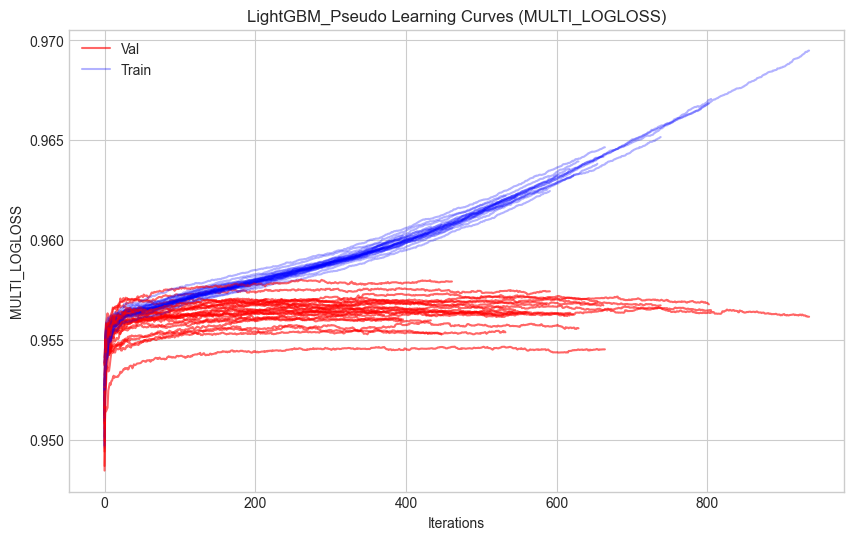

In [14]:
mviz = ModelVisualizer(model_name='LightGBM_Pseudo')

mviz.plot_learning_curves(eval_results, metric='multi_logloss')

### Feature Importance
This bar chart ranks features by average gain across all folds.
* **Validation check:** lifestyle and body indicators like `bmi`, `sleep_duration`, `step_count`, `stress_level`, `exercise_duration` should dominate. If none of these appear near the top, something is wrong upstream.
* **Feature check:** interaction features like `lifestyle_risk_score`, `sleep_quality_index`, and `calories_per_step` should rank highly if their corresponding strategies are active in `fe_strategies`.
* **Leakage check:** `id` must not appear in the chart at all.

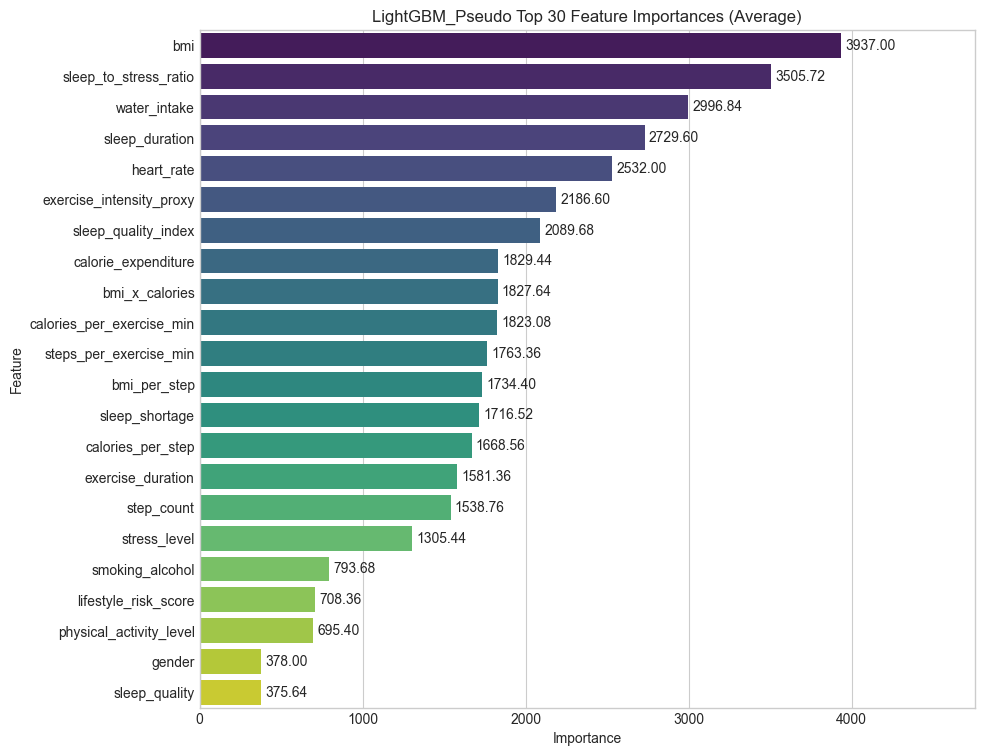

In [15]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (at-risk=0, unhealthy=1, fit=2). A large divergence on one class suggests the model is systematically misclassifying that stellar type.

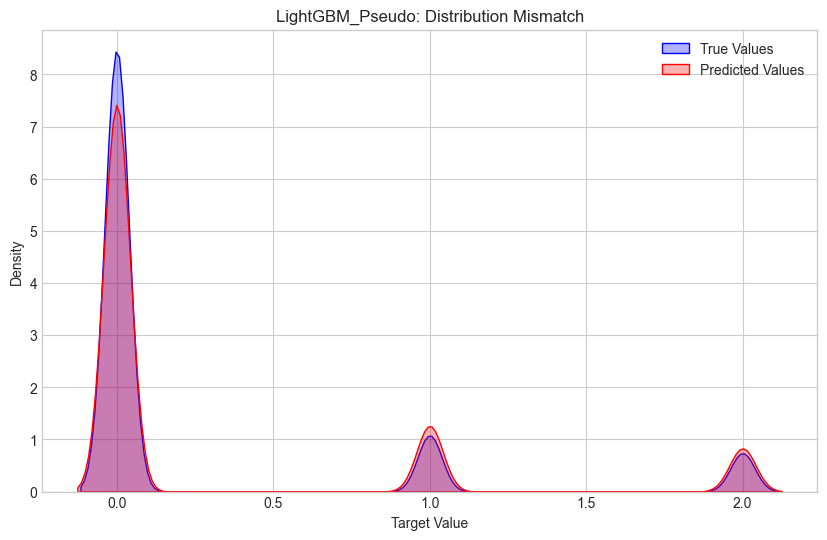

In [16]:
mviz.plot_distribution_mismatch(y_true=y[filled_mask], y_preds=oof_preds[filled_mask])

### Multiclass ROC Curve (One-vs-Rest)
Each class is treated as the positive class in turn. The AUC for each curve measures how well the model separates that class from the other two. All three curves should sit well above the diagonal; a sagging at-risk or unhealthy curve indicates a struggle to separate the specific risk levels.

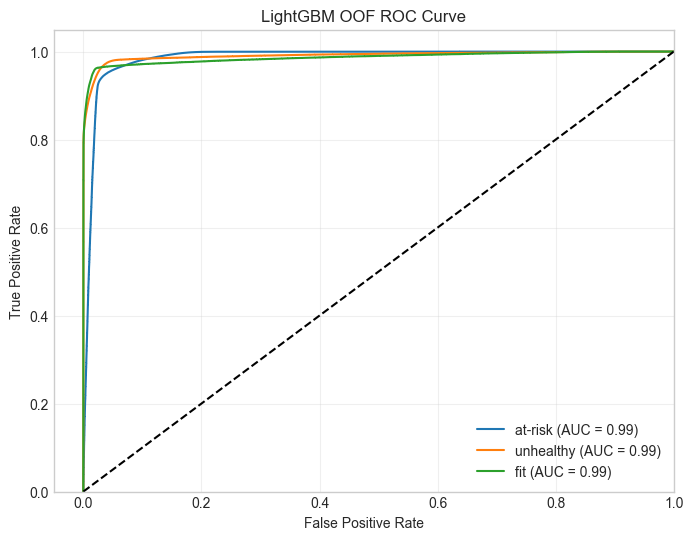

In [17]:
mviz.plot_multiclass_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask], title='LightGBM OOF ROC Curve')

Normalized confusion matrix


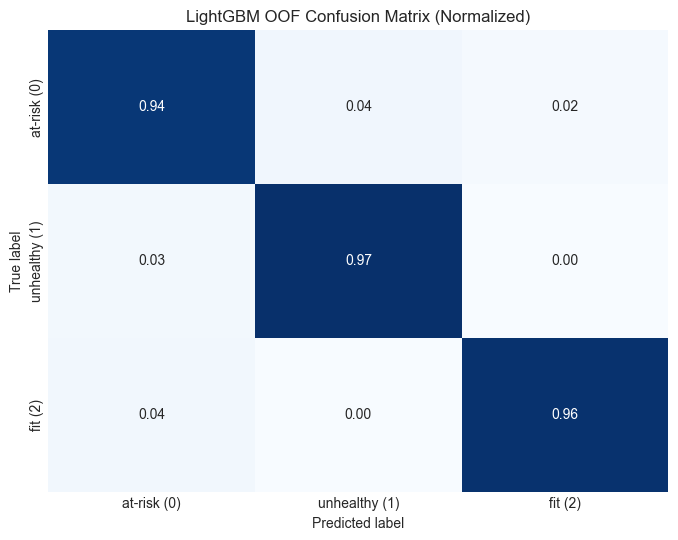

In [18]:
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=oof_preds[filled_mask],
    classes=['at-risk (0)', 'unhealthy (1)', 'fit (2)'],
    normalize=True,
    title='LightGBM OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires the hard predicted class label (`at-risk`, `unhealthy`, or `fit`) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [19]:
submission_df = setup.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,fit
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk


In [20]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

OOF and averaged test-set probabilities are saved for downstream ensembling (blending or stacking). For this three-class task we save the full probability distribution across `at-risk`, `unhealthy`, and `fit` rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

For blending reference see Tilii's excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [21]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: at-risk=0, unhealthy=1, fit=2
prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']

# OOF probabilities
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_df = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y.values}),
    oof_prob_df
], axis=1)
oof_df = oof_df[filled_mask]
oof_df.to_csv(f'{output_dir}/lgb_pseudo_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/lgb_pseudo_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/lgb_pseudo_oof_probs.csv\n - {output_dir}/lgb_pseudo_test_probs.csv')

Saved for ensembling:
 - predictions/lgb_pseudo_oof_probs.csv
 - predictions/lgb_pseudo_test_probs.csv
